In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

%config InlineBackend.figure_format = 'svg'

def read_adf07_ionization_file(filepath, species_key = 'N'):
    """
    Parses ADAS ADF07 ionization coefficient files (e.g., szd96#n_n0.dat).
    These files contain electron impact ionization rate coefficients.
    """
    try:
        with open(filepath, 'r') as f:
            content = f.read()
    except FileNotFoundError:
        # This is expected if a file for a certain charge state doesn't exist.
        return None
    
    # Split into lines
    lines = content.splitlines()
    
    # Find data blocks (they start with charge state info like "N + 0/N + 1/")
    data_blocks = []
    i = 0
    while i < len(lines):
        line = lines[i]
        # Look for lines with charge state transitions for Nitrogen
        if f'{species_key} +' in line and '/' in line and 'I.P.' in line:
            # Parse header
            header = line
            charge_info = header.split('/')[0:2]
            initial_state = charge_info[0].strip()
            final_state = charge_info[1].strip()
            
            # Extract ionization potential if present
            ip_match = re.search(r'I\.P\.\s*=\s*([\d.]+)', header)
            ip_cm = float(ip_match.group(1)) if ip_match else None
            
            # Next lines contain temperature grid
            i += 1
            temp_values = []
            # Find all temperature and rate values, which are listed consecutively
            all_values_str = ""
            while i < len(lines) and not (lines[i].startswith('C--') or lines[i].strip() == '' or 'ISEL' in lines[i]):
                # Replace Fortran's 'D' with 'E' for scientific notation
                all_values_str += lines[i].replace('D', 'E') + " "
                i += 1
            
            all_values = [float(x) for x in all_values_str.split()]
            num_points = len(all_values) // 2

            if num_points > 0:
                temp_values = all_values[:num_points]
                rate_values = all_values[num_points:]

                if len(temp_values) == len(rate_values):
                    data_blocks.append({
                        'initial': initial_state,
                        'final': final_state,
                        'ip_cm': ip_cm,
                        'temp_eV': np.array(temp_values),
                        'rate_cm3_s': np.array(rate_values)
                    })
        else:
            i += 1
    
    return data_blocks

def parse_all_adf07_files(download_dir, species_key = 'N'):
    """
    Parse all ADF07 nitrogen ionization files (szd96#n_n0.dat through szd96#n_n6.dat).
    """
    all_data = {}
    
    for charge_state in range(7):  # N0 through N6
        filename = f"{species_key}{charge_state}.dat"
        filepath = download_dir / filename
        
        if not filepath.exists():
            continue

        print(f"Reading {filename}...")
        data_blocks = read_adf07_ionization_file(filepath, species_key)
        
        if data_blocks:
            # Use the first data block (total ionization rate, usually ISEL=1)
            block = data_blocks[0]
            
            # Create DataFrame
            df = pd.DataFrame({
                'Te_eV': block['temp_eV'],
                'Rate_cm3_s': block['rate_cm3_s']
            })
            
            # Store with transition key
            state_key = f'{species_key}{charge_state}+ -> {species_key}{charge_state+1}+'
            all_data[state_key] = df
            
            print(f"  Found data for {state_key}: {len(df)} temperature points")

    return all_data

def calculate_cpp_rate(Te_eV, E_ioniz_eV, a_ioniz, q_ioniz):
    """Calculates the ionization rate using a modified Arrhenius formula."""
    Te_eV_safe = np.maximum(Te_eV, 1e-99)
    rate = a_ioniz * (Te_eV_safe ** q_ioniz) * np.exp(-E_ioniz_eV / Te_eV_safe)
    return rate

def fit_ionization_coefficient(adas_df, E_ioniz_eV, fit_temp_eV, q_ioniz):
    """
    Fits the a_ioniz coefficient at a specific temperature for a given q.
    """
    # Interpolate ADAS rate at the fitting temperature
    adas_rate_at_fit_temp = np.interp(fit_temp_eV, adas_df['Te_eV'], adas_df['Rate_cm3_s'])
    
    # Calculate the a_ioniz coefficient
    denominator = (fit_temp_eV ** q_ioniz) * np.exp(-E_ioniz_eV / fit_temp_eV)
    if denominator > 0:
        a_ioniz_fit = adas_rate_at_fit_temp / denominator
    else:
        a_ioniz_fit = 0.0
    
    return a_ioniz_fit, adas_rate_at_fit_temp

## Hydrogen : https://open.adas.ac.uk/detail/adf07/szd93][h/szd93][h_h0.dat

ADAS ADF07 Nitrogen Ionization Data Parser
 (Searching for files in: .)

Reading H0.dat...
  Found data for H0+ -> H1+: 24 temperature points

Fitting ionization coefficients to C++ formula

H0+ -> H1+: (E_ioniz = 13.60 eV)
  Fit at T = 10.0 eV with q = 0.400
  Fitted a_ioniz = 8.250e-09


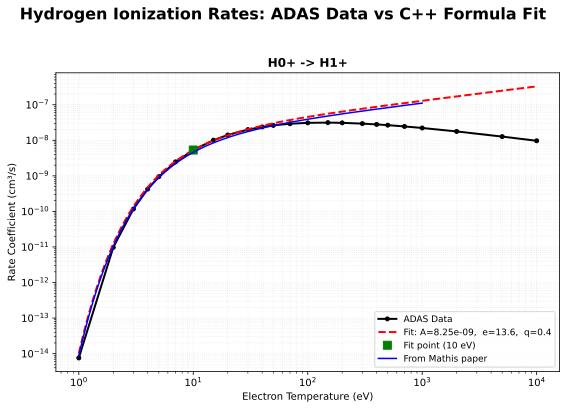


RECOMMENDED C++ COEFFICIENTS FOR problem_source.H

// Hydrogen collisional ionization rate coefficients
// Fitted from ADAS ADF07 data files (szd96#n_n*.dat)
// Rate = a_ioniz * (Te_eV^q_ioniz) * exp(-E_ioniz_eV/Te_eV)


In [14]:
home_dir = Path.home()
download_dir = Path("./")

print("="*60)
print("ADAS ADF07 Nitrogen Ionization Data Parser")
print(f" (Searching for files in: {download_dir})")
print("="*60)
print()

# Parse all available ADF07 files from the downloads directory
adas_data = parse_all_adf07_files(download_dir, species_key='H')

if adas_data:
    print("\n" + "="*60)
    print("Fitting ionization coefficients to C++ formula")
    print("="*60)
    
    # Define ionization energies and fitting parameters for Nitrogen
    # You may need to adjust q_ioniz and fit_temp_eV for best results
    fit_params = {
        'H0+ -> H1+':  {'E_ioniz_eV': 13.60,  'q_ioniz': 0.4, 'fit_temp_eV': 10.0},
    }
    
    new_cpp_coeffs = {}
    available_states = [key for key in fit_params.keys() if key in adas_data]
    num_states = len(available_states)
    
    if num_states > 0:
        # Setup figure
        ncols = 2 if num_states > 1 else 1
        nrows = (num_states + 1) // 2 if num_states > 1 else 1
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8, 6), squeeze=False)
        fig.suptitle("Hydrogen Ionization Rates: ADAS Data vs C++ Formula Fit", fontsize=16, fontweight='bold')
        axes = axes.flatten()
        
        for idx, state_key in enumerate(available_states):
            df = adas_data[state_key]
            params = fit_params[state_key]
            ax = axes[idx]
            
            E_ioniz, q_ioniz, fit_temp = params['E_ioniz_eV'], params['q_ioniz'], params['fit_temp_eV']
            
            a_ioniz_fit, adas_rate_at_fit = fit_ionization_coefficient(df, E_ioniz, fit_temp, q_ioniz)
            new_cpp_coeffs[state_key] = (a_ioniz_fit, q_ioniz, E_ioniz)
            
            # Plotting
            ax.loglog(df['Te_eV'], df['Rate_cm3_s'], 'ko-', label='ADAS Data', markersize=4, lw=2)
            te_fine = np.logspace(np.log10(df['Te_eV'].min()), np.log10(df['Te_eV'].max()), 200)
            cpp_rates = calculate_cpp_rate(te_fine, E_ioniz, a_ioniz_fit, q_ioniz)
            ax.loglog(te_fine, cpp_rates, 'r--', label=f'Fit: A={a_ioniz_fit:.2e},  e={E_ioniz},  q={q_ioniz}', lw=2)
            ax.plot(fit_temp, adas_rate_at_fit, 'gs', markersize=8, label=f'Fit point ({fit_temp:.0f} eV)')
            
            print(f"\n{state_key}: (E_ioniz = {E_ioniz:.2f} eV)")
            print(f"  Fit at T = {fit_temp:.1f} eV with q = {q_ioniz:.3f}")
            print(f"  Fitted a_ioniz = {a_ioniz_fit:.3e}")
            
            # Formatting
            ax.set_title(state_key, fontweight='bold')
            ax.set_xlabel("Electron Temperature (eV)")
            ax.set_ylabel("Rate Coefficient (cm³/s)")
            ax.grid(True, which='both', ls=':', alpha=0.3)


        # Hide unused subplots
        for i in range(num_states, len(axes)):
            axes[i].set_visible(False)

        def model(Te, a, e, q):
            return a * (Te ** q) * np.exp(-e / Te)
        Te = np.logspace(0, 3, 1000)
        ax.plot(Te, model(Te, 7.1e-15 * 1e6, 13.6, 0.4), 'b-', label='From Mathis paper')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        ax.legend(loc='best', fontsize=9)
        plt.savefig('hydrogen_ionization_fits.png', dpi=400)
        plt.show()

    # Output final coefficients
    print("\n" + "="*60)
    print("RECOMMENDED C++ COEFFICIENTS FOR problem_source.H")
    print("="*60)
    print("\n// Hydrogen collisional ionization rate coefficients")
    print("// Fitted from ADAS ADF07 data files (szd96#n_n*.dat)")
    print("// Rate = a_ioniz * (Te_eV^q_ioniz) * exp(-E_ioniz_eV/Te_eV)")

## https://open.adas.ac.uk/detail/adf07/szd96%5D%5Bn/szd96%5D%5Bn_n0.dat 

ADAS ADF07 Nitrogen Ionization Data Parser
 (Searching for files in: .)

Reading N0.dat...
  Found data for N0+ -> N1+: 24 temperature points
Reading N1.dat...
  Found data for N1+ -> N2+: 24 temperature points
Reading N2.dat...
  Found data for N2+ -> N3+: 24 temperature points
Reading N3.dat...
  Found data for N3+ -> N4+: 24 temperature points
Reading N4.dat...
  Found data for N4+ -> N5+: 24 temperature points
Reading N5.dat...
  Found data for N5+ -> N6+: 21 temperature points
Reading N6.dat...
  Found data for N6+ -> N7+: 21 temperature points

Fitting ionization coefficients to C++ formula

N0+ -> N1+: (E_ioniz = 14.53 eV)
  Fit at T = 10.0 eV with q = 0.5
  Fitted a_ioniz = 1.110e-08

N1+ -> N2+: (E_ioniz = 29.60 eV)
  Fit at T = 10.0 eV with q = 0.5
  Fitted a_ioniz = 4.094e-09

N2+ -> N3+: (E_ioniz = 47.45 eV)
  Fit at T = 10.0 eV with q = 0.5
  Fitted a_ioniz = 2.462e-09

N3+ -> N4+: (E_ioniz = 77.47 eV)
  Fit at T = 10.0 eV with q = 0.5
  Fitted a_ioniz = 7.949e-10

N4+ -> 

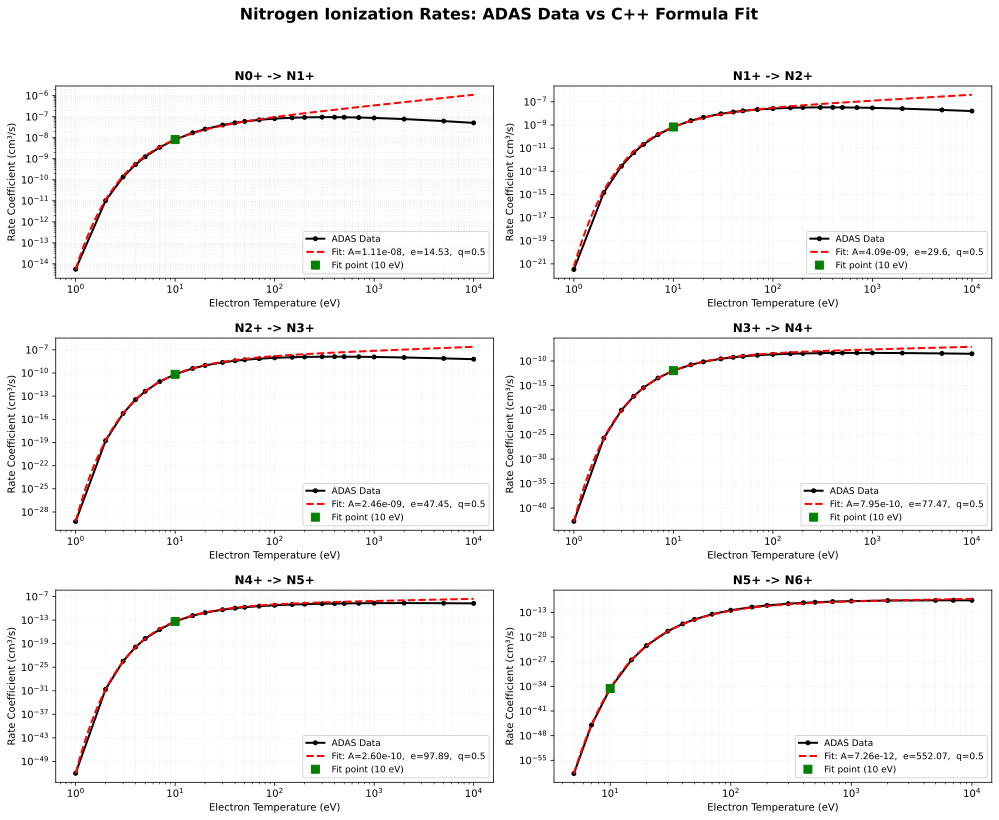


RECOMMENDED C++ COEFFICIENTS FOR problem_source.H

// Nitrogen collisional ionization rate coefficients
// Fitted from ADAS ADF07 data files (szd96#n_n*.dat)
// Rate = a_ioniz * (Te_eV^q_ioniz) * exp(-E_ioniz_eV/Te_eV)


In [12]:
home_dir = Path.home()
download_dir = Path("./")

print("="*60)
print("ADAS ADF07 Nitrogen Ionization Data Parser")
print(f" (Searching for files in: {download_dir})")
print("="*60)
print()

# Parse all available ADF07 files from the downloads directory
adas_data = parse_all_adf07_files(download_dir, species_key='N')

if adas_data:
    print("\n" + "="*60)
    print("Fitting ionization coefficients to C++ formula")
    print("="*60)
    
    # Define ionization energies and fitting parameters for Nitrogen
    # You may need to adjust q_ioniz and fit_temp_eV for best results
    fit_params = {
        'N0+ -> N1+':  {'E_ioniz_eV': 14.53,  'q_ioniz': 0.5, 'fit_temp_eV': 10.0},
        'N1+ -> N2+':  {'E_ioniz_eV': 29.60,  'q_ioniz': 0.5, 'fit_temp_eV': 10.0},
        'N2+ -> N3+':  {'E_ioniz_eV': 47.45,  'q_ioniz': 0.5, 'fit_temp_eV': 10.0},
        'N3+ -> N4+':  {'E_ioniz_eV': 77.47,  'q_ioniz': 0.5, 'fit_temp_eV': 10.0},
        'N4+ -> N5+':  {'E_ioniz_eV': 97.89,  'q_ioniz': 0.5, 'fit_temp_eV': 10.0},
        'N5+ -> N6+':  {'E_ioniz_eV': 552.07, 'q_ioniz': 0.5, 'fit_temp_eV': 10.0},
    }
    
    new_cpp_coeffs = {}
    available_states = [key for key in fit_params.keys() if key in adas_data]
    num_states = len(available_states)
    
    if num_states > 0:
        # Setup figure
        ncols = 2 if num_states > 1 else 1
        nrows = (num_states + 1) // 2 if num_states > 1 else 1
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4*nrows), squeeze=False)
        fig.suptitle("Nitrogen Ionization Rates: ADAS Data vs C++ Formula Fit", fontsize=16, fontweight='bold')
        axes = axes.flatten()
        
        for idx, state_key in enumerate(available_states):
            df = adas_data[state_key]
            params = fit_params[state_key]
            ax = axes[idx]
            
            E_ioniz, q_ioniz, fit_temp = params['E_ioniz_eV'], params['q_ioniz'], params['fit_temp_eV']
            
            a_ioniz_fit, adas_rate_at_fit = fit_ionization_coefficient(df, E_ioniz, fit_temp, q_ioniz)
            new_cpp_coeffs[state_key] = (a_ioniz_fit, q_ioniz)
            
            # Plotting
            ax.loglog(df['Te_eV'], df['Rate_cm3_s'], 'ko-', label='ADAS Data', markersize=4, lw=2)
            te_fine = np.logspace(np.log10(df['Te_eV'].min()), np.log10(df['Te_eV'].max()), 200)
            cpp_rates = calculate_cpp_rate(te_fine, E_ioniz, a_ioniz_fit, q_ioniz)
            ax.loglog(te_fine, cpp_rates, 'r--', label=f'Fit: A={a_ioniz_fit:.2e},  e={E_ioniz},  q={q_ioniz}', lw=2)
            ax.plot(fit_temp, adas_rate_at_fit, 'gs', markersize=8, label=f'Fit point ({fit_temp:.0f} eV)')
            
            print(f"\n{state_key}: (E_ioniz = {E_ioniz:.2f} eV)")
            print(f"  Fit at T = {fit_temp:.1f} eV with q = {q_ioniz}")
            print(f"  Fitted a_ioniz = {a_ioniz_fit:.3e}")
            
            # Formatting
            ax.set_title(state_key, fontweight='bold')
            ax.set_xlabel("Electron Temperature (eV)")
            ax.set_ylabel("Rate Coefficient (cm³/s)")
            ax.grid(True, which='both', ls=':', alpha=0.3)
            ax.legend(loc='best', fontsize=9)

        # Hide unused subplots
        for i in range(num_states, len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig('nitrogen_ionization_fits.png', dpi=400)
        plt.show()

    # Output final coefficients
    print("\n" + "="*60)
    print("RECOMMENDED C++ COEFFICIENTS FOR problem_source.H")
    print("="*60)
    print("\n// Nitrogen collisional ionization rate coefficients")
    print("// Fitted from ADAS ADF07 data files (szd96#n_n*.dat)")
    print("// Rate = a_ioniz * (Te_eV^q_ioniz) * exp(-E_ioniz_eV/Te_eV)")

